In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import pandas as pd
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import time
import requests
from torchsummary import summary
import math

In [18]:
file_location='./input.txt'

with open(file_location) as f:
    text=f.read().strip()
chars= sorted(list(set(text)))
char_to_idx= dict()
idx_to_char = dict()
for index,val in enumerate(chars):
    char_to_idx[val]=index
    idx_to_char[index]=val

#encode text
vocab_size=len(char_to_idx)
encoded_text= [char_to_idx[ch]for ch in text]
print(f" text length: {len(text)} characters")
print(f"vocab_size: {vocab_size}")
print(f"First 20 encoded: {encoded_text[:20]}")
print(f"Which decodes to: {''.join([idx_to_char[i] for i in encoded_text[:20]])}")

 text length: 2386 characters
vocab_size: 45
First 20 encoded: [13, 23, 42, 38, 1, 21, 26, 19, 36, 19, 21, 38, 23, 36, 1, 34, 36, 23, 22, 27]
Which decodes to: Next character predi


In [19]:
def create_input_output_seq(encoded_text,seq_len):
    inputs=[]
    targets=[]
    for i in range(len(encoded_text)-seq_len):
        input_seq=encoded_text[i:i+seq_len]
        target_seq=encoded_text[i+1:i+seq_len+1]
        inputs.append(input_seq)
        targets.append(target_seq)
    X=np.array(inputs)
    y=np.array(targets)

    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
    X_train=torch.tensor(X_train,dtype=torch.long)
    X_test=torch.tensor(X_test,dtype=torch.long)
    y_train=torch.tensor(y_train,dtype=torch.long)
    y_test=torch.tensor(y_test,dtype=torch.long)

    print(f"\nseq_len = {seq_len}")
    print(f"  Total samples : {len(X)}")
    print(f"  X_train shape : {X_train.shape}")   # (N_train, seq_len)
    print(f"  y_train shape : {y_train.shape}")   # (N_train, seq_len)
    print(f"  X_test shape   : {X_test.shape}")
    print(f"  y_test shape   : {y_test.shape}")

    return X_train, X_test, y_train, y_test

In [20]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model,dropout,max_length=1000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        encoding = torch.zeros(max_length, d_model)
        position = torch.arange(0, max_length, dtype=torch.float).reshape(-1,1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        encoding[:, 0::2] = torch.sin(position * div_term)
        encoding[:, 1::2] = torch.cos(position * div_term)
        encoding = encoding.unsqueeze(0)
        self.register_buffer('encoding', encoding)
    def forward(self, x):
        return self.dropout(x + self.encoding[:, :x.size(1)].detach())

    


In [21]:
class CharTransformer(nn.Module):
    def __init__(self, eta, n_iter,batch_size, random_state, vocab_size, hidden_size,num_layers,nhead, dropout=0.2):
        super().__init__()
        self.eta=eta
        self.n_iter = n_iter
        self.batch_size=batch_size
        self.random_state= random_state
        self.hidden_size = hidden_size
        self.vocab_size= vocab_size

        torch.manual_seed(self.random_state)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
        print(f'Using {self.device}')

        self.embedding=nn.Embedding(vocab_size,hidden_size)
        self.pos_encoder = PositionalEncoding(hidden_size,dropout)
        encoder_layers = nn.TransformerEncoderLayer(hidden_size, nhead, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.softmax = nn.Softmax(dim=2)

        self.train_losses_     = []
        self.train_accuracies_ = []
        self.val_losses_       = []
        self.val_accuracies_   = []
        self.to(self.device)
    
    def forward(self,x):
        seq_len = x.size(1)
        causal_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(x.device)
        embedded = self.embedding(x)
        embedded = self.pos_encoder(embedded)
        transformer_output = self.transformer_encoder(embedded, mask= causal_mask)
        output = self.fc(transformer_output)
        return output
    
    def iter_mini_batch(self,X,y):
        dataSet=TensorDataset(X,y)
        dataLoader=DataLoader(dataSet, batch_size=self.batch_size,shuffle=True)
        return dataLoader
    
    def fit(self,X_train,y_train,X_test,y_test):
        start_time=time.time()
        optimizer = optim.Adam(self.parameters(),lr=self.eta, weight_decay=0.001)
        criterion= nn.CrossEntropyLoss()

        for epoch in range(self.n_iter):
            epoch_start=time.time()
            self.train()
            train_loader=self.iter_mini_batch(X_train,y_train)
            running_loss=0.0
            correct=0
            total =0

            for xin,target in train_loader:
                xin=xin.to(self.device)
                target=target.to(self.device)
                optimizer.zero_grad()
                y_hat=self(xin)
                loss = criterion(y_hat.view(-1, y_hat.size(-1)), target.view(-1))
                loss.backward()
                optimizer.step()

                running_loss+=loss.item()
                preds = y_hat.argmax(dim=-1)
                correct += (preds == target).sum().item()
                total += target.numel()
            epoch_time =time.time()-epoch_start
            epoch_loss = running_loss / len(train_loader)
            epoch_acc  = 100.0 * correct / total

            self.train_losses_.append(epoch_loss)
            self.train_accuracies_.append(epoch_acc)

            val_loss, val_acc = self._evaluate(X_test, y_test, criterion)
            self.val_losses_.append(val_loss)
            self.val_accuracies_.append(val_acc)
            current_lr = optimizer.param_groups[0]['lr']

            print(f'Epoch {epoch+1:>3}/{self.n_iter} | '
                  f'Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}% | '
                  f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% |'
                  f'lr: {current_lr:.6f} |'
                  f'Time: {epoch_time:.1f}s')

        self.training_time_ = time.time() - start_time    #stop the clock
        mins = self.training_time_ // 60
        secs = self.training_time_ % 60
        print(f"\nTraining complete: {int(mins)}m {secs:.1f}s")
        return self

    def _evaluate(self, X_test, y_test, criterion):
        test_loader=self.iter_mini_batch(X_test,y_test)
        self.eval()
        running_loss = 0.0
        correct      = 0
        total        = 0
        with torch.no_grad():
            for xin, target in test_loader:
                xin = xin.to(self.device)
                target = target.to(self.device)

                outputs = self(xin)
                loss=criterion(outputs.view(-1, outputs.size(-1)), target.view(-1))

                running_loss+= loss.item()
                predicted = outputs.argmax(dim=-1)
                total += target.numel()
                correct += (predicted == target).sum().item()
        val_loss = running_loss / len(test_loader)
        val_acc  = 100.0 * correct / total
        return val_loss, val_acc
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [22]:
seq_lengths = [10, 20, 30]
datasets = {}
models = {}


hp = dict(eta=1e-3, n_iter=50, batch_size=32, random_state=42,
          vocab_size=vocab_size, hidden_size=64, num_layers=2, nhead=4, dropout=0.1)

for sl in seq_lengths:
    X_train, X_test, y_train, y_test = create_input_output_seq(encoded_text, sl)
    datasets[sl] = (X_train, X_test, y_train, y_test)

    model = CharTransformer(**hp)
    model.fit(X_train, y_train, X_test, y_test)
    models[sl] = model


seq_len = 10
  Total samples : 2376
  X_train shape : torch.Size([1900, 10])
  y_train shape : torch.Size([1900, 10])
  X_test shape   : torch.Size([476, 10])
  y_test shape   : torch.Size([476, 10])
Using mps
Epoch   1/50 | Loss: 2.7169 | Acc: 24.23% | Val Loss: 2.3491 | Val Acc: 31.66% |lr: 0.001000 |Time: 0.7s
Epoch   2/50 | Loss: 2.2754 | Acc: 33.01% | Val Loss: 2.1271 | Val Acc: 38.00% |lr: 0.001000 |Time: 0.7s
Epoch   3/50 | Loss: 2.0721 | Acc: 39.68% | Val Loss: 1.9569 | Val Acc: 44.29% |lr: 0.001000 |Time: 0.7s
Epoch   4/50 | Loss: 1.9236 | Acc: 43.28% | Val Loss: 1.8061 | Val Acc: 46.20% |lr: 0.001000 |Time: 0.7s
Epoch   5/50 | Loss: 1.8060 | Acc: 45.79% | Val Loss: 1.6931 | Val Acc: 49.43% |lr: 0.001000 |Time: 0.7s
Epoch   6/50 | Loss: 1.7082 | Acc: 48.75% | Val Loss: 1.5952 | Val Acc: 51.22% |lr: 0.001000 |Time: 0.7s
Epoch   7/50 | Loss: 1.6256 | Acc: 50.14% | Val Loss: 1.5348 | Val Acc: 52.86% |lr: 0.001000 |Time: 0.8s
Epoch   8/50 | Loss: 1.5540 | Acc: 51.66% | Val Loss: 

In [ ]:

for sl, model in models.items():
    print(f"seq_len={sl}: {model.count_parameters():,} trainable parameters")



seq_len=10: 568,109 trainable parameters
seq_len=20: 568,109 trainable parameters
seq_len=30: 568,109 trainable parameters


In [24]:

rows = []
for sl in seq_lengths:
    model = models[sl]
    n_params = model.count_parameters()
    theoretical_attn_flops = sl**2 * hp['hidden_size'] * hp['num_layers']
    rows.append({
        'seq_len': sl,
        'params': n_params,
        'final_train_loss': model.train_losses_[-1],
        'final_val_acc': model.val_accuracies_[-1],
        'training_time_s': model.training_time_,
        'theoretical_attn_compute (n^2 * d * layers)': theoretical_attn_flops,
    })

pd.DataFrame(rows)

,seq_len,params,final_train_loss,final_val_acc,training_time_s,theoretical_attn_compute (n^2 * d * layers)
0,10,568109,0.904894,73.634454,34.626972,12800
1,20,568109,0.584902,86.540084,34.240312,51200
2,30,568109,0.447810,90.670904,34.025669,115200


In [25]:
def plot_curves(model, title):
  epochs = range(1, len(model.train_losses_) + 1)

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

  ax1.plot(epochs, model.train_losses_,
            label='Train loss',
            color='steelblue',
            linewidth=1.8,
            marker='o', markersize=2)

  ax1.plot(epochs, model.val_losses_,
            label='Val loss',
            color='tomato',
            linewidth=1.8,
            linestyle='--',
            marker='o', markersize=2)

  ax1.set_xlabel('Epoch', fontsize=12)
  ax1.set_ylabel('Cross-entropy loss', fontsize=12)
  ax1.set_title('Loss per epoch', fontsize=13)
  ax1.legend(fontsize=11)
  ax1.grid(True, alpha=0.3)

  ax2.plot(epochs, model.train_accuracies_,
            label='Train accuracy',
            color='steelblue',
            linewidth=1.8,
            marker='o', markersize=2)

  ax2.plot(epochs, model.val_accuracies_,
            label='Val accuracy',
            color='tomato',
            linewidth=1.8,
            linestyle='--',
            marker='o', markersize=2)

  ax2.set_xlabel('Epoch', fontsize=12)
  ax2.set_ylabel('Accuracy (%)', fontsize=12)
  ax2.set_title('Accuracy per epoch', fontsize=13)
  ax2.set_ylim(0, 100)
  ax2.legend(fontsize=11)
  ax2.grid(True, alpha=0.3)

  plt.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
  plt.tight_layout()
  plt.show()

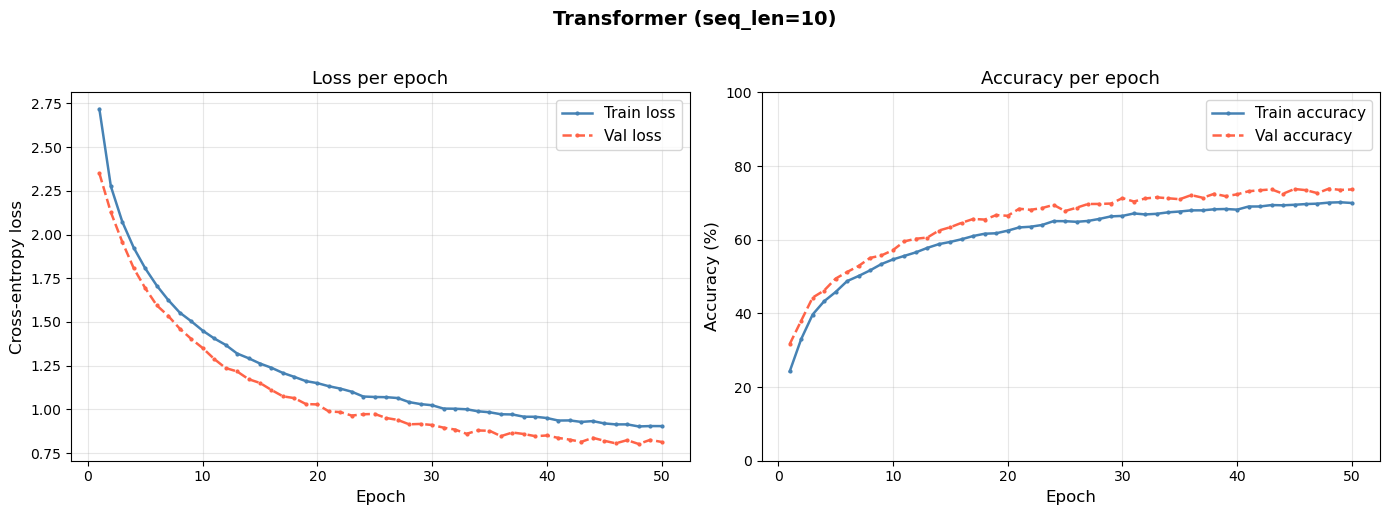

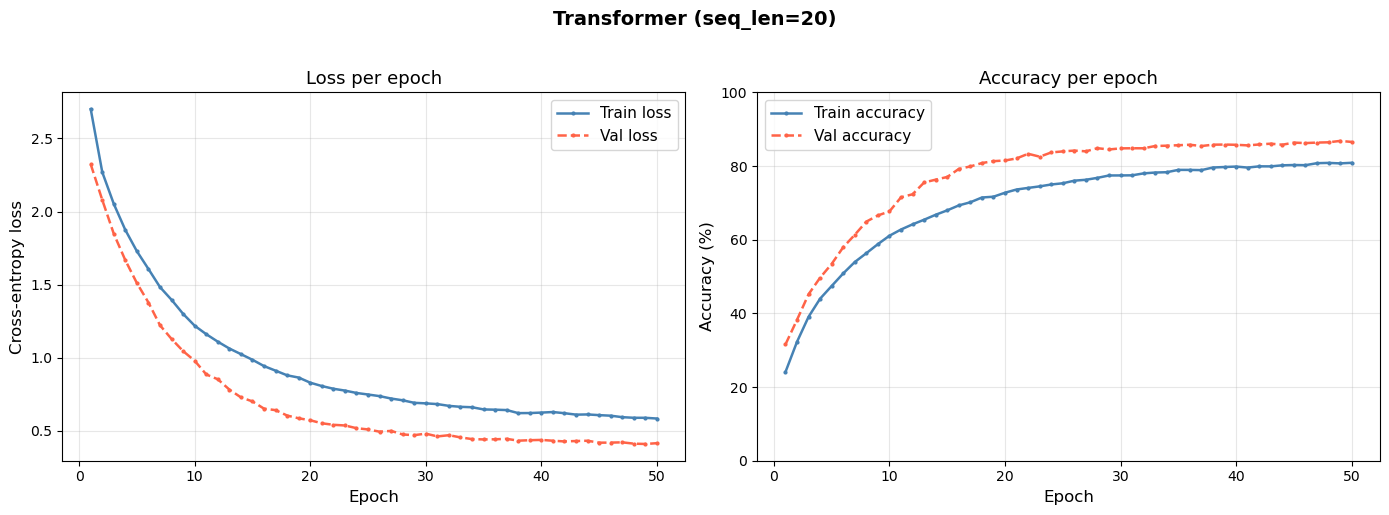

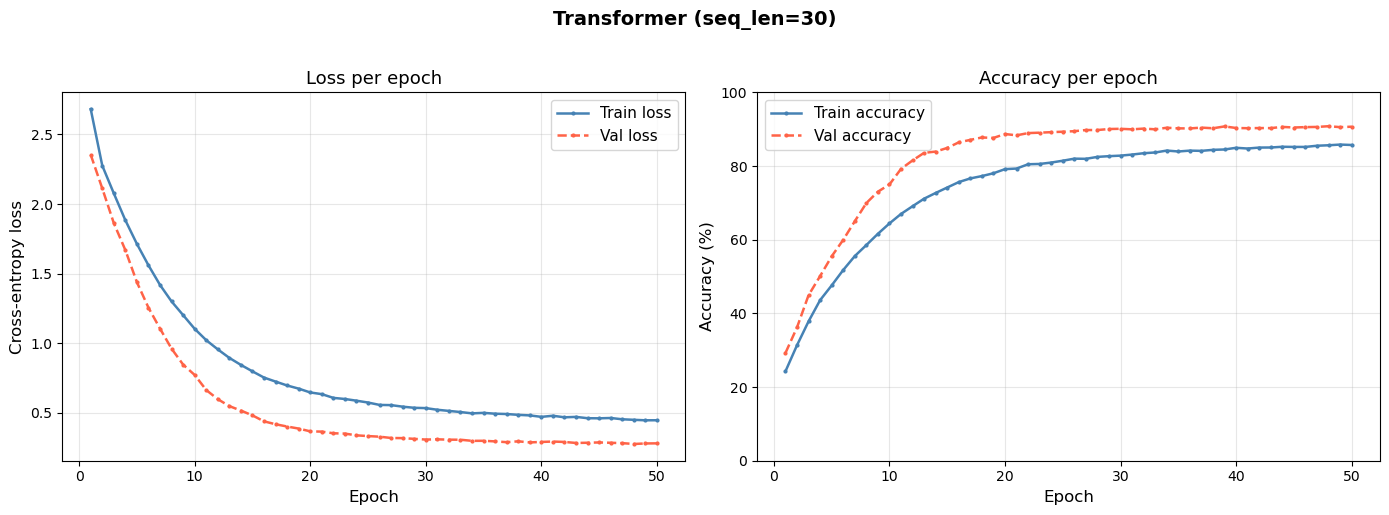

In [26]:
for seq_len, model in models.items():
    plot_curves(model, title=f"Transformer (seq_len={seq_len})")

In [27]:
def load_shakespeare():
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    response = requests.get(url)
    text = response.text  # This is the entire text data
    chars=sorted(list(set(text)))
    char_to_idx= dict()
    idx_to_char = dict()
    for index,val in enumerate(chars):
        char_to_idx[val]=index
        idx_to_char[index]=val

    vocab_size=len(char_to_idx)
    encoded_text= [char_to_idx[ch]for ch in text]
    print(f" text length: {len(text)} characters")
    print(f"vocab_size: {vocab_size}")
    print(f"First 20 encoded: {encoded_text[:20]}")
    print(f"Which decodes to: {''.join([idx_to_char[i] for i in encoded_text[:20]])}")
    return encoded_text
shakespeare_encoded_text=load_shakespeare()

 text length: 1115394 characters
vocab_size: 65
First 20 encoded: [18, 47, 56, 57, 58, 1, 15, 47, 58, 47, 64, 43, 52, 10, 0, 14, 43, 44, 53, 56]
Which decodes to: First Citizen:
Befor


In [29]:
BATCH_SIZE = 128
N_ITER = 5
baseline_results = {}
for sl in [20, 30]:
    X_train, X_test, y_train, y_test = create_input_output_seq(shakespeare_encoded_text, sl)
    model = CharTransformer(eta=1e-3, n_iter=N_ITER, batch_size=BATCH_SIZE, random_state=42,
                             vocab_size=65, hidden_size=64, num_layers=2, nhead=2, dropout=0.1)
    model.fit(X_train, y_train, X_test, y_test)
    baseline_results[sl] = model

sweep_results = []
X_train, X_test, y_train, y_test = create_input_output_seq(shakespeare_encoded_text, seq_len=20)

for num_layers in [1, 2, 4]:
    for nhead in [2, 4]:
        model = CharTransformer(eta=1e-3, n_iter=N_ITER, batch_size=BATCH_SIZE, random_state=42,
                                 vocab_size=65, hidden_size=64, num_layers=num_layers,
                                 nhead=nhead, dropout=0.1)
        model.fit(X_train, y_train, X_test, y_test)

        final_val_loss = model.val_losses_[-1]
        perplexity = math.exp(final_val_loss)

        sweep_results.append({
            'num_layers': num_layers,
            'nhead': nhead,
            'params': model.count_parameters(),
            'final_train_loss': model.train_losses_[-1],
            'final_val_loss': final_val_loss,
            'val_perplexity': perplexity,
            'final_val_acc': model.val_accuracies_[-1],
            'training_time_s': model.training_time_,
        })

sweep_df = pd.DataFrame(sweep_results)    


seq_len = 20
  Total samples : 1115374
  X_train shape : torch.Size([892299, 20])
  y_train shape : torch.Size([892299, 20])
  X_test shape   : torch.Size([223075, 20])
  y_test shape   : torch.Size([223075, 20])
Using mps
Epoch   1/5 | Loss: 2.1218 | Acc: 37.82% | Val Loss: 1.9063 | Val Acc: 43.43% |lr: 0.001000 |Time: 112.2s
Epoch   2/5 | Loss: 1.9947 | Acc: 41.11% | Val Loss: 1.8545 | Val Acc: 44.69% |lr: 0.001000 |Time: 112.2s


KeyboardInterrupt: 

In [ ]:
X_train, X_test, y_train, y_test = create_input_output_seq(shakespeare_encoded_text, seq_len=50)
model_50 = CharTransformer(eta=1e-3, n_iter=N_ITER, batch_size=BATCH_SIZE, random_state=42,
                            vocab_size=65, hidden_size=64, num_layers=2, nhead=2, dropout=0.1)
model_50.fit(X_train, y_train, X_test, y_test)

print(f"params: {model_50.count_parameters()}")
print(f"final val loss: {model_50.val_losses_[-1]:.4f}, "
      f"val acc: {model_50.val_accuracies_[-1]:.2f}%, "
      f"perplexity: {math.exp(model_50.val_losses_[-1]):.2f}")